# 1. Загрузка изображения в оттенках серого

In [189]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

# 2. Построение гистограммы

(400, 600)


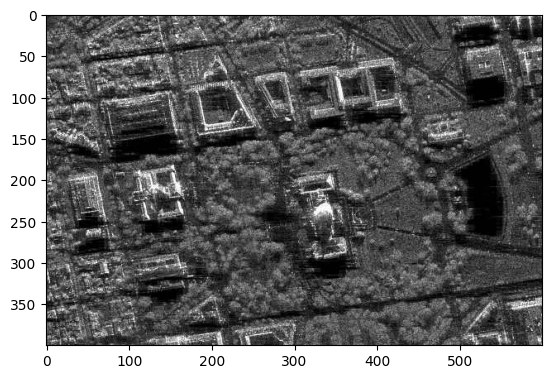

In [190]:
image = cv2.imread('sar_1_gray.jpg', 0)
print(image.shape)
plt.imshow(image, cmap='gray') 
plt.show()

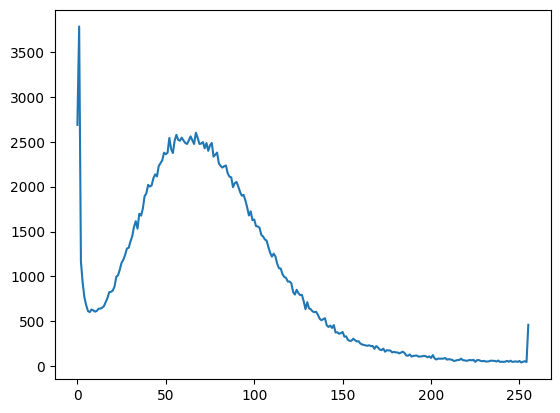

In [191]:
histSize = 256
histRange = (0, 256)
accumulate = False

gray_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(gray_hist)

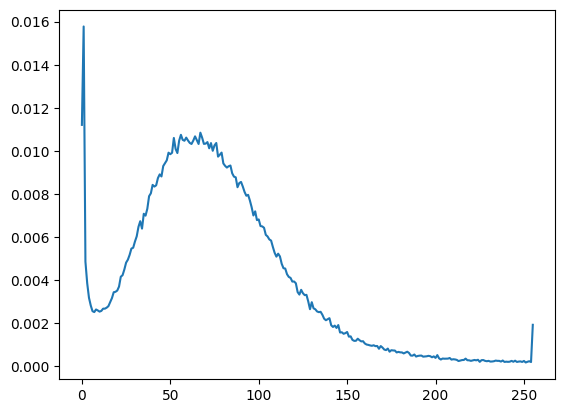

In [192]:
gray_hist_norm = gray_hist /  (image.shape[0] * image.shape[1])
plt.plot(gray_hist_norm)

# 3. Реализация алгоритма гамма-коррекции ($\gamma < 1$ и $\gamma > 1$)

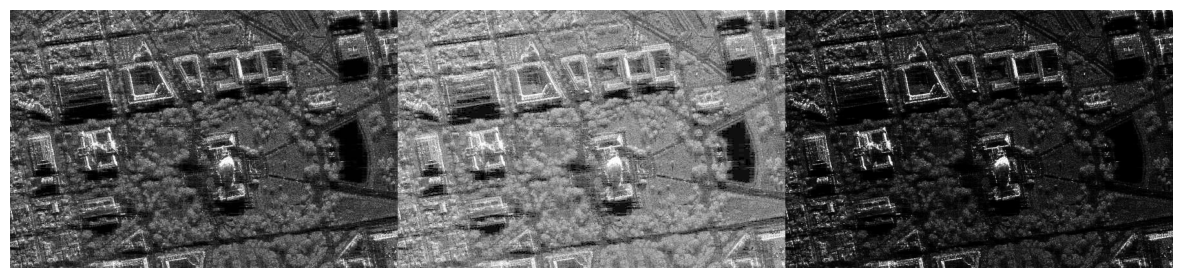

In [193]:
def apply_gamma(img, gamma):
    # Прямая формула: gamma > 1 делает темнее, gamma < 1 делает светлее
    return np.uint8(np.power(img / 255.0, gamma) * 255)

img_gamma_low = apply_gamma(image, 0.5)  # Гамма < 1
img_gamma_high = apply_gamma(image, 1.8) # Гамма > 1

# Визуализация результатов
plt.figure(figsize=(15, 5))
plt.imshow(np.hstack((image, img_gamma_low, img_gamma_high)), cmap='gray')
plt.axis('off'); plt.show()

# 4. Сравнение изображений с помощью метрик MSE и SSIM

In [194]:
# 1. Расчет MSE (чем меньше, тем больше похожи изображения)
mse_low = mean_squared_error(image, img_gamma_low)
mse_high = mean_squared_error(image, img_gamma_high)

# 2. Расчет SSIM (от 0 до 1, где 1 — полная идентичность)
ssim_low = structural_similarity(image, img_gamma_low, data_range=255)
ssim_high = structural_similarity(image, img_gamma_high, data_range=255)

print(f"Сравнение с Gamma 0.5: MSE = {mse_low:.2f}, SSIM = {ssim_low:.4f}")
print(f"Сравнение с Gamma 1.8: MSE = {mse_high:.2f}, SSIM = {ssim_high:.4f}")

Сравнение с Gamma 0.5: MSE = 3250.43, SSIM = 0.7875
Сравнение с Gamma 1.8: MSE = 1837.90, SSIM = 0.6316


# 5. Статистическая цветокоррекция на основе эталона

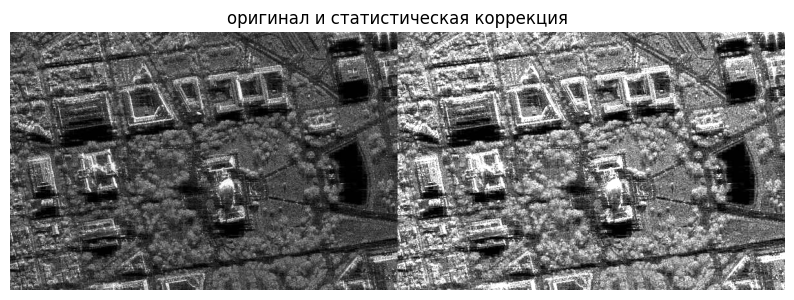

In [195]:
# 1. Получаем эталонную статистику из эквализированного изображения
eq_gray = cv2.equalizeHist(image)
m_t, s_t = eq_gray.mean(), eq_gray.std()

# 2. Реализация коррекции: (I - mean) / std * std_target + mean_target
# clip ограничивает значения в диапазоне [0, 255]
stat_corrected = np.clip((image - image.mean()) / image.std() * s_t + m_t, 0, 255).astype(np.uint8)

# 3. Вывод результата
plt.figure(figsize=(10, 5))
plt.imshow(np.hstack((image, stat_corrected)), cmap='gray')
plt.title('оригинал и статистическая коррекция')
plt.axis('off'); plt.show()

# 6. Тестирование алгоритмов пороговой фильтрации

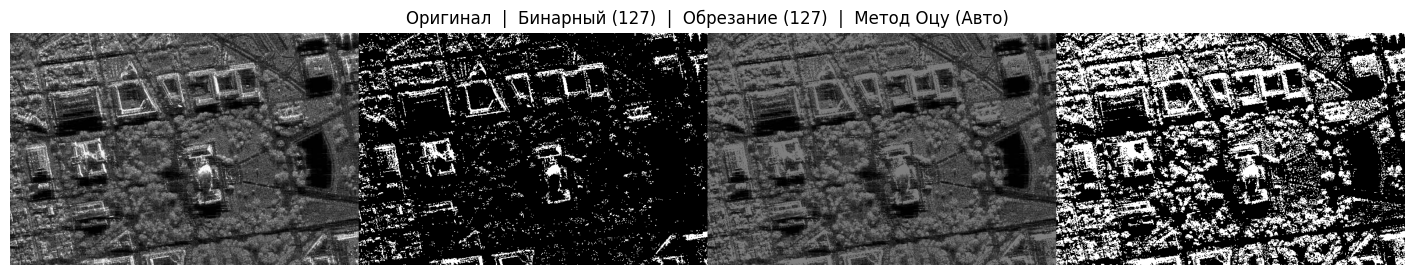

In [196]:
# 1. Бинарный фильтр (Порог 127)
_, th_bin = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# 2. Обрезка (Truncate)
_, th_trunc = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)

# 3. Метод Оцу (Автоматический порог)
_, th_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Визуализация результатов
plt.figure(figsize=(18, 5))
plt.imshow(np.hstack((image, th_bin, th_trunc, th_otsu)), cmap='gray')
plt.title('Оригинал  |  Бинарный (127)  |  Обрезание (127)  |  Метод Оцу (Авто)')
plt.axis('off'); plt.show()

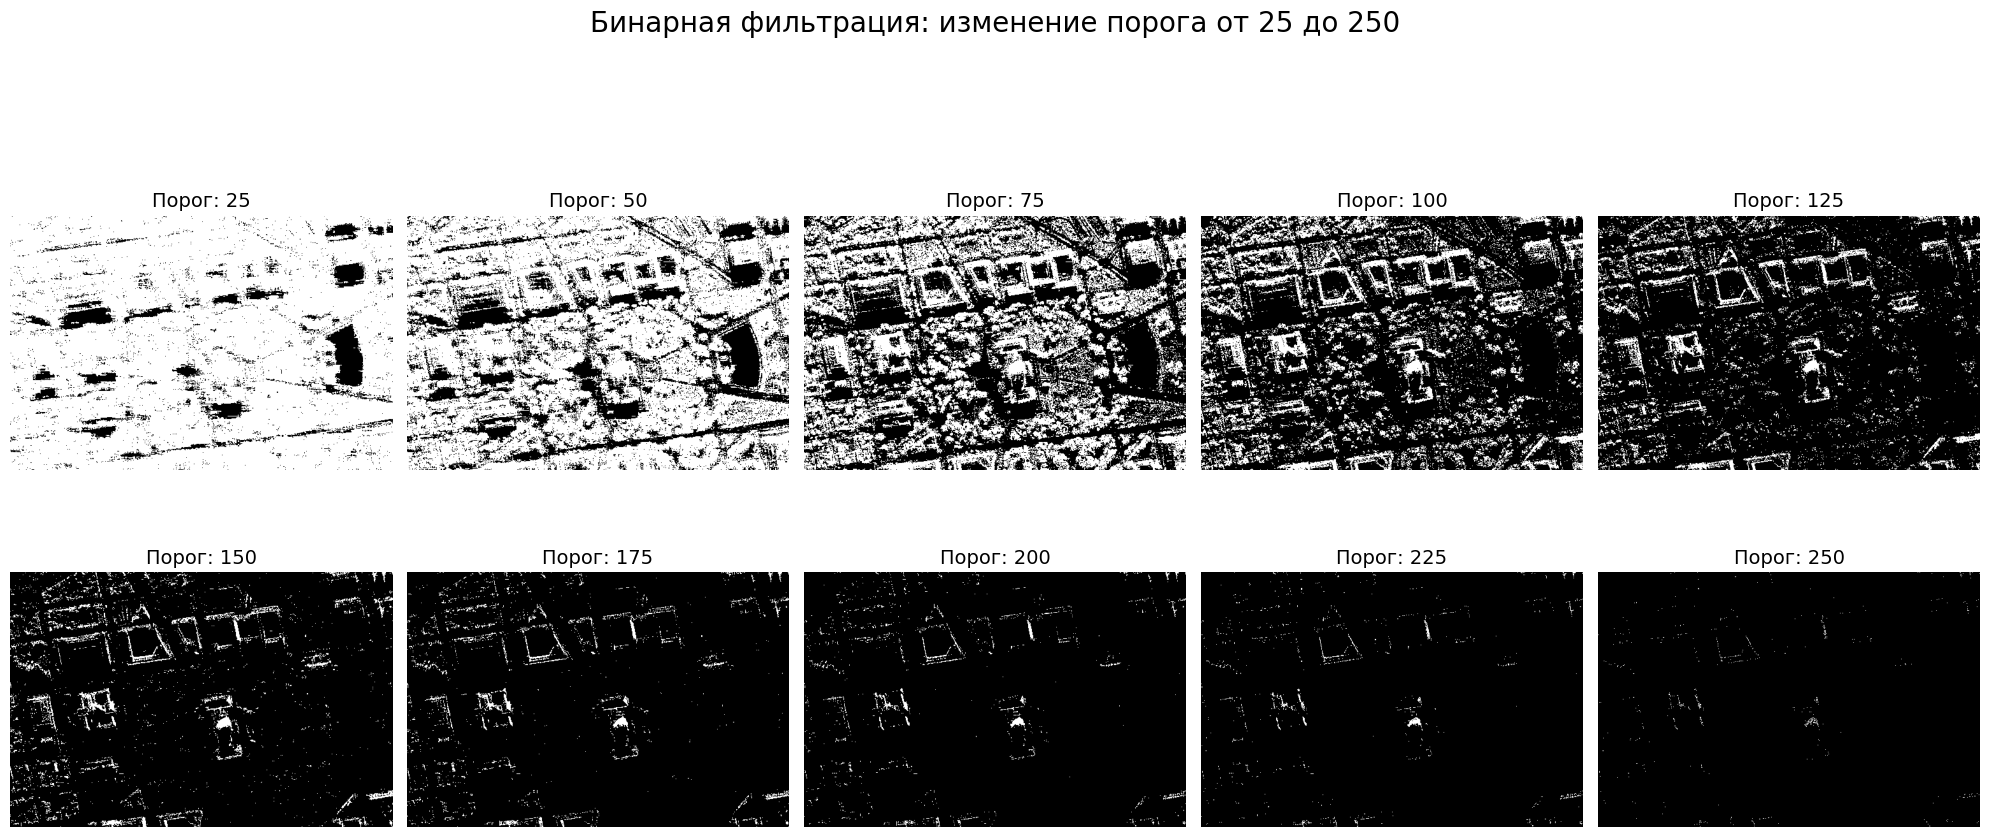

In [197]:
threshold_values = range(25, 251, 25)

# Создаем сетку 2 строки по 5 картинок
fig, axes = plt.subplots(2, 5, figsize=(20, 10)) 
fig.suptitle('Бинарная фильтрация: изменение порога от 25 до 250', fontsize=20)

for i, thresh in enumerate(threshold_values):
    _, res = cv2.threshold(image, thresh, 255, cv2.THRESH_BINARY)
    
    # Определяем координаты в сетке (ax)
    ax = axes[i // 5, i % 5]
    ax.imshow(res, cmap='gray')
    ax.set_title(f'Порог: {thresh}', fontsize=14)
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

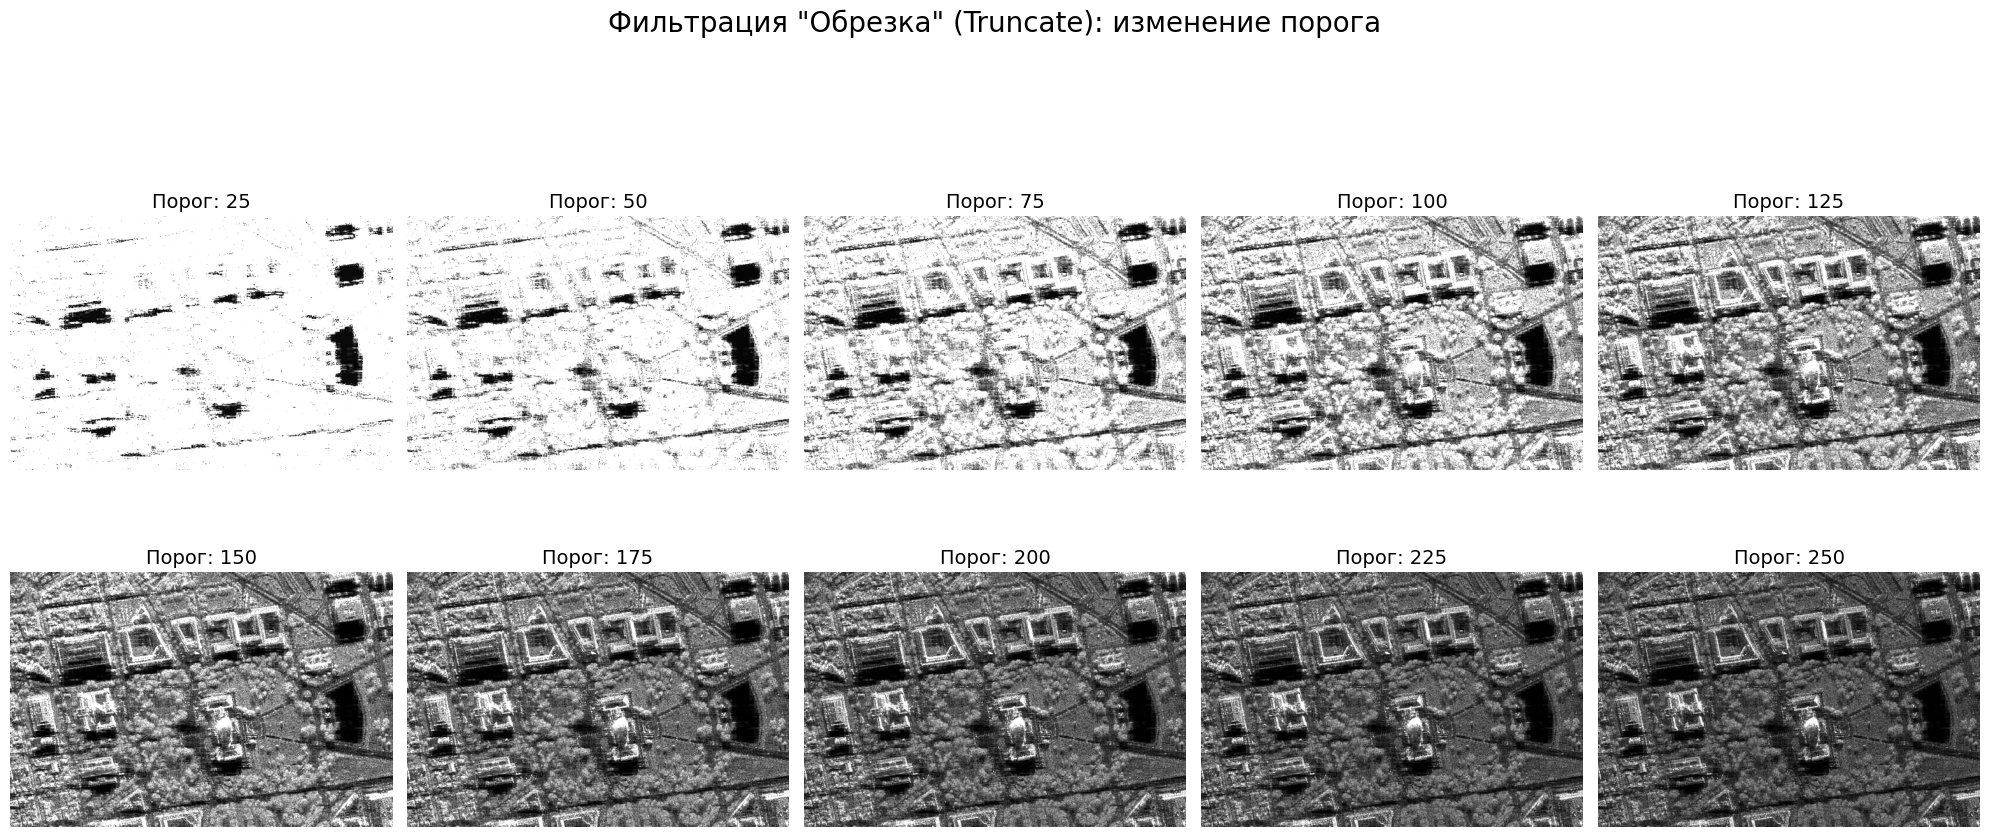

In [198]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Фильтрация "Обрезка" (Truncate): изменение порога', fontsize=20)

for i, thresh in enumerate(threshold_values):
    _, res = cv2.threshold(image, thresh, 255, cv2.THRESH_TRUNC)
    
    ax = axes[i // 5, i % 5]
    ax.imshow(res, cmap='gray')
    ax.set_title(f'Порог: {thresh}', fontsize=14)
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()